# Twitter Sentiment Analysis using BERT Notebook 6

In [1]:
# installing libraries
# !pip install torch==2.0.0 --quiet
# !pip install torchtext==0.15.1 --quiet
# !pip install transformers==4.35.0 --quiet
!pip install emot --quiet
!pip install unidecode  --quiet
!pip install ftfy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00


In [2]:
# import libraries

# library to interacte with file and time operations
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Libraries for working with regular expressions
import re
import emot
from emot.emo_unicode import EMOTICONS_EMO
from string import punctuation
import html
import unidecode

# # Librarie from torchtext
# import torchtext
# from torchtext.data.utils import get_tokenizer

# NLP libraries from nltk for stopwords
import nltk
from nltk.corpus import stopwords

# basic library
import pandas as pd
import numpy as np

# visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from tqdm import tqdm
from tqdm import tnrange



# Deep learning libraries using PyTorch
import torch

# Deep learning libraries using Hugging Face
import transformers
from transformers import BertTokenizer

#
import ftfy

In [3]:
# new library import



In [4]:
# setting the env variable for kaggle download
os.environ['KAGGLE_CONFIG_DIR'] = "."

# downloading the files
!kaggle datasets download kazanova/sentiment140

# unzip the files in .\data folder
!unzip sentiment140.zip -d data

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
 91% 74.0M/80.9M [00:00<00:00, 137MB/s]
100% 80.9M/80.9M [00:00<00:00, 120MB/s]
Archive:  sentiment140.zip
  inflating: data/training.1600000.processed.noemoticon.csv  


## Loading the data

In [19]:
dataset = pd.read_csv("/content/data/training.1600000.processed.noemoticon.csv", encoding = "utf-8", encoding_errors = "replace",
                      names = ['target', 'ids', 'date', 'flag', 'user', 'text'])
dataset.drop(labels = ['ids', 'date', 'flag','user'], axis = 1, inplace = True)
dataset.sample(5)

,target,text
914610,4,@officialTila Thanks for the interview mama! ...
2654,0,dear twitter... i have 4 bug bites on my leg. ...
67071,0,@iammandurr wow I only have like 30 lol. No on...
1406318,4,@JulieAdore woohoo!fun!! who r u going with?h...
1305776,4,@jaredleto thinkin about you guys new album an...


In [20]:
# check info about the dataset
dataset.info(memory_usage = "deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   text    1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 213.4 MB


In [21]:
# check for null values
dataset.isnull().sum()

,0
target,0
text,0


In [22]:
dataset = dataset.sample(200000).copy()
dataset.shape

(200000, 2)

In [23]:
# replace 4 with 1 for better understanding
dataset['target'] = dataset['target'].replace(4,1)
print(dataset.target.unique())

[0 1]


In [24]:
# correcting issue with the text accentuate words
dataset['text']= dataset['text'].apply(ftfy.fix_text)

In [25]:
# remove username
def remove_username(text):
  text = re.sub(r"@\w+","",text)
  return re.sub(r"\s+", " ", text).strip()

In [26]:
def remove_hashtags(text):
  text = re.sub(r"#\w+", "", text)
  return re.sub(r"\s+", " ", text).strip()

In [27]:
# remove links from tweets
def remove_links(text):
  # remove links starting with https or http
  text = re.sub(r"\bhttps?://\S+", "", text)
  # remove links starting with www.
  text = re.sub(r"\bwww\.\S+", "", text)
  # remove links ending with .com
  text = re.sub(r"\b\S+\.com\b", "", text)
  return re.sub(r"\s+", " ", text).strip()

In [28]:
# convert emoticons to text
def replace_emoticons(text):
    pattern = re.compile(r'(' + '|'.join(re.escape(k) for k in EMOTICONS_EMO.keys()) + r')')
    return pattern.sub(lambda x: EMOTICONS_EMO[x.group()], text)


In [29]:
# remove unidecode words
def remove_unidecode_words(text):
  words = text.split()
  filtered_words = [word for word in words if unidecode.unidecode(word) == word]
  return ' '.join(filtered_words)

In [30]:
def reduce_repeated_chars(text):
    return re.sub(r'(\w)\1{2,}', r'\1\1', text)

In [31]:
# group all the above functions in one functions
def text_processing(text):
  text = remove_username(text)
  text = remove_links(text)
  text = replace_emoticons(text)
  text = remove_unidecode_words(text)
  text = reduce_repeated_chars(text)
  # Remove trailing whitespace
  text = re.sub(r'\s+', ' ', text).strip()
  return text

In [32]:
# Preprocessing the tweets from the dataset

# startime
start_time = time.time()

# store the processed data in new list
new_tweets = []

# start the pre-processing
for sent in dataset['text']:
  sent = text_processing(sent)
  new_tweets.append(sent)

dataset['text'] = new_tweets
print(f" Text pre-processing completed.... Elapsed time : {time.time()-start_time} secs")

 Text pre-processing completed.... Elapsed time : 35.67922282218933 secs


In [33]:
dataset['text'].sample(10)

,text
1239772,- Beautiful scottish summer
852548,jammin to the one and only Mary Magdalan! MJL
1532170,Thank you!
1559885,"Yay Nephew Brody Said ""Cakkie"""
1463890,"Off to the beach, second weekend running, this..."
1042590,Sorry you won't be joining us...since you'll b...
1406052,welcome backish! im heading off the eureka tmr...
1354240,how kids get through the day with out a drink ...
102184,i miss my old school
1178325,I am happy i slpet over at my cousins house!


## Setting GPU for training

In [34]:
# import library
import torch

In [35]:
# set GPU for training if available
if torch.cuda.is_available():
  device = torch.device("cuda")
  print(f'There are {torch.cuda.device_count()} GPUs available.')
  print(f"Device select for training : {torch.cuda.get_device_name(0)}")

else:
  device = torch.device('cpu')
  print("No GPU available, using the CPU instead.")


There are 1 GPUs available.
Device select for training : Tesla T4


## Fine-Tuning BERT

### 1. Install the Hugging Face library

The transformer library of Hugging Face contains Pytorch implementation of state of the art NLP models including BERT, GPT and pre-trained model weights.

In [36]:
# install transformer from Hugging Face
!pip install transformers --quiet

### 2. Tokenization and input Foramtting

For our current dataset, we have already performed Text- preprocessing in Notebook-1 where we have removed username, html links and various other. Therfore we can proceed with direct tokenization or we can explore text preprocessing later on.

In [37]:
"""
Perform Text processing on the complete dataset from Kaggle
"""

'\nPerform Text processing on the complete dataset from Kaggle\n'

### 2.1 BERT Tokenizer

To utilize a pre-trained BERT model, we need to use the tokenizer provided by the library for the following reasons:

1. The BERT model operates with a predefined and fixed vocabulary.
2. The BERT tokenizer follows a specific approach to processing out-of-vocabulary words.


Additionally, it is necessary to:
1. Add special tokens at the beginning and end of each sentence.
2. Pad and truncate all sentences to a fixed length.
3. Explicitly define padding tokens using the "attention mask."

The encode_plus method of BERT tokenizer will:
1. split our text into tokens
2. add the special [CLS] and [SEP] tokens
3. convert these tokens into indexes of the tokenizer vocabulary
4. Pad or truncate sentences to max length, and
5. Create attention mask.

In [38]:
# import tokenizer from BERT
from transformers import BertTokenizer

# import WhitespaceTokenizer from nltk
from nltk.tokenize import WhitespaceTokenizer

In [39]:
# Initialize the BertTokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case = True)

ws_tokenizer = WhitespaceTokenizer()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

,count,mean,std,min,25%,50%,75%,90%,95%,98.5%,max
text,200000.0,12.68424,7.014152,0.0,7.0,12.0,18.0,23.0,25.0,28.0,48.0


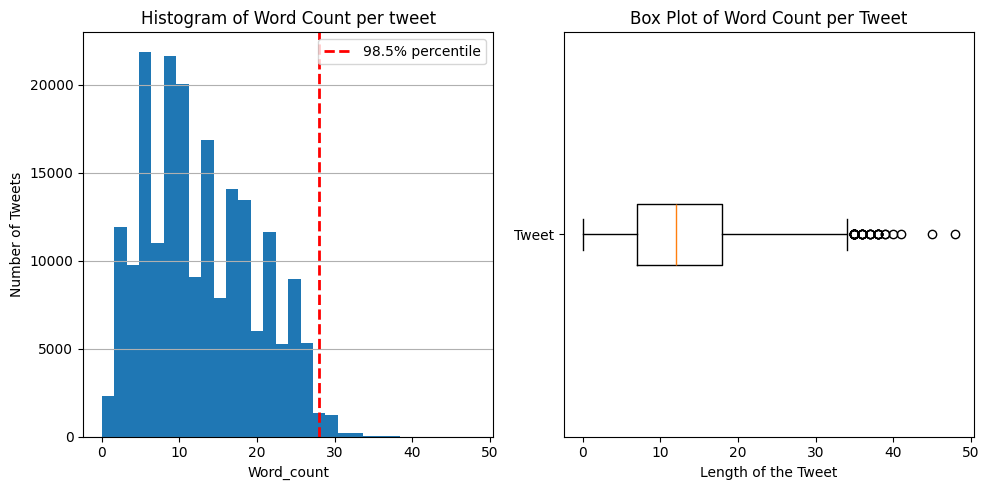

In [40]:
# calculate the lenght of each tweet in dataset and store in len_tweet
len_tweet = dataset['text'].map(ws_tokenizer.tokenize).map(len)

# check descriptive statistic for length of the tweets
describe = pd.DataFrame(len_tweet.describe()).T
## calculating 90%, 95% and 98.5% percentile length of the tweets
percentile_90 = len_tweet.quantile(0.90)
percentile_95 = len_tweet.quantile(0.95)
percentile_985 = len_tweet.quantile(0.985)
# appending 90,95 and 98.5 percentile values to descirbe
describe['90%'] = percentile_90
describe['95%'] = percentile_95
describe['98.5%'] = percentile_985

# rearranging the columns orders
describe = describe[[col for col in describe.columns if col != 'max']+['max']]
display(describe)

# histogram of word count per tweets
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.hist(len_tweet,bins = 30)
plt.title("Histogram of Word Count per tweet")
plt.axvline(percentile_985, color = 'red', linestyle = 'dashed', linewidth = 2,
            label = '98.5% percentile')
plt.xlabel("Word_count")
plt.ylabel("Number of Tweets")
plt.legend()
plt.grid(axis = 'y')

# Boxplot of word count per tweet
plt.subplot(1,2,2)
plt.boxplot(list(len_tweet), vert = False)
plt.title("Box Plot of Word Count per Tweet")
plt.xlabel("Length of the Tweet")
plt.yticks([1],["Tweet"])

# Adjust the layout
plt.tight_layout()
plt.show()

In [42]:
# Define the maximum length for tweet
MAX_LENGTH = 28

In [43]:
# function for tokenization
def preprocessing_for_bert(data):
  """Perfrom required preprocessing steps for pretrained BERT.
    @param    data(np.array):               Array of texts to be processed.
    @return   input_ids(torch.tensor):      Tenor of tokens ids to be fed to the BERT model.
    @return   attention_mask(torch.tensor): Tensor of indices specifying which tokens
                                            should be attended to by the model.
  """
  # empty list to store outputs
  input_ids = []
  attention_masks = []

  for sent in data:
    # encode_plus will:
    # 1. Tokenize the sentence
    # 2. Add the [CLS] and [SEP] token to the start and end
    # 3. Truncate/Pad sentence to max length
    # 4. Map tokens to their IDS
    # 5. create attention mask
    # 6. Return a dictionary of outputs
    encoded_sent = bert_tokenizer.encode_plus(
        text = sent,                        # Preprocessing sentences
        add_special_tokens = True,          # Add [CLS] and [SEP]
        max_length = MAX_LENGTH,       # Max Length to Truncate/Pad
        padding = 'max_length',           # Pad sentence to max_length
        # return_tensors = 'pt',            # Return Pytorch tensor
        return_attention_mask = True,# return attention mask
        truncation = True
        )

    # store the output to the list
    input_ids.append(encoded_sent.get('input_ids'))
    attention_masks.append(encoded_sent.get('attention_mask'))

  # convert to tensor
  input_ids = torch.tensor(input_ids)
  attention_masks = torch.tensor(attention_masks)


  return input_ids, attention_masks



In [44]:
# Experiment
test_1 = dataset[0:10]
test_inputs, test_train_masks= preprocessing_for_bert(test_1['text'])
test_inputs, test_train_masks

(tensor([[  101,  1045,  2123,  1005,  1056,  2228,  1045,  2064,  2907,  2041,
           2006,  9992,  1996, 19960,  2015,  2151,  2936,  1012, 14978,  2003,
           2205,  2844,  1012,  5683,  2066,  2619,  4711,   102],
         [  101,  2041,  2007, 15419,  1010, 15730,  1010, 10905,  3401,  2063,
           1010,  9965,  1010,  1998,  5553,  2483,  2012, 14465,  2015,  1012,
           1012,  1012,  1012,  2293,  2122,  3057,   102,     0],
         [  101,  4299,  1045,  2071,  2156,  2651,  1005,  1055,  2208,  1010,
           2057,  1005,  2128,  2304,  2098,  2041,  2182,  2175, 23178,  2015,
            999,   102,     0,     0,     0,     0,     0,     0],
         [  101,  2383,  1005, 11937, 21756,  2053, 26156,  1005,  2005,  6265,
           3461,  1012,  1012,  1012,   102,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0],
         [  101,  5580,  2009,  8509,  2017,  1999,  1996,  2851,  6888,  1012,
           1

### 2.3 Spliting data into Training and Testing data

In [45]:
# import train_test_split from sklearn
from sklearn.model_selection import train_test_split

In [46]:
# Ratio of split
TEST_RATIO = 0.1
VAL_RATIO  = 0.2

# Split the data into temp and test data
X_Temp_Train, X_Test, y_temp_train, y_test = train_test_split(dataset['text'],
                                                              dataset['target'],
                                                              test_size = TEST_RATIO,
                                                              random_state = 42,
                                                              )

# Split the X_Temp_Train and y_temp_train into Training and Validation set
X_Train, X_Val, y_train, y_val = train_test_split(X_Temp_Train,
                                                  y_temp_train,
                                                  test_size = VAL_RATIO,
                                                  random_state = 42)

In [47]:
# check the length of training, validation and test data
len(X_Train),len(X_Val), len(X_Test)

(144000, 36000, 20000)

Let's tokenize the train and validation data

In [48]:
# Experiment
token_ids = preprocessing_for_bert([test_1['text'].iloc[1]])
print("original",test_1['text'].iloc[1])
print("token ids", token_ids[0])

original Out with jen,joanna,kaycee,janet,and janis at dennys....love these girls
token ids tensor([[  101,  2041,  2007, 15419,  1010, 15730,  1010, 10905,  3401,  2063,
          1010,  9965,  1010,  1998,  5553,  2483,  2012, 14465,  2015,  1012,
          1012,  1012,  1012,  2293,  2122,  3057,   102,     0]])


In [77]:
start_time = time.time()
print("Tokenizing data .....")
# tokenizing train data
train_inputs, train_masks = preprocessing_for_bert(X_Train)

# tokeinizing validatoin data
val_inputs, val_masks = preprocessing_for_bert(X_Val)

# Tokenizing test data
test_inputs, test_masks = preprocessing_for_bert(X_Test)

print(f"Tokenization completed..... Elapsed time {time.time()-start_time} secs")

Tokenizing data .....
Tokenization completed..... Elapsed time 73.17727184295654 secs


In [78]:
display(train_inputs[0],train_masks[0])

tensor([  101,  2026,  2204,  2305,  2299,  1012,  1012,  1012,  1026,  3943,
         6919,  3892,  1066, 11928,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0])

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])

In [79]:
display(train_inputs.shape, train_masks.shape)

torch.Size([144000, 28])

torch.Size([144000, 28])

## 2.2 Create PyTorch Dataloader

We will create an iterator for our dataset using the torch DataLoader class which will help on saving memory during training and boosting training speed.

In [80]:
# import library
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

In [81]:
# Convert target data to torch.Tenosr
train_labels = torch.tensor(y_train.values, dtype = torch.long )
val_labels = torch.tensor(y_val.values, dtype = torch.long)
test_labels = torch.tensor(y_test.values, dtype = torch.long)

# BATCH size for fine_tuning BERT
BATCH_SIZE = 64

# DataLoader for training set
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data,sampler = train_sampler,
                              batch_size = BATCH_SIZE, num_workers = 8)

# Dataloader for Validation set
val_data = TensorDataset(val_inputs, val_masks, val_labels)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler = val_sampler,
                            batch_size = BATCH_SIZE*2, num_workers = 8)

# DataLoader for Test set
test_data = TensorDataset(test_inputs, test_masks, test_labels)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler = test_sampler,
                             batch_size = BATCH_SIZE*2, num_workers = 8)


## 3. Train BERT Model

### 3.1 BERT Classifier

In [82]:
# import libraries
import torch
import torch.nn as nn
from transformers import BertModel

In [83]:
# %%time
# Bert Classifier

class BertClassifier(nn.Module):
  def __init__(self,freeze_bert = False):
    super(BertClassifier, self).__init__()

    # Hidden size of BERT, hidden size of classifier and number of labels
    D_in, H, D_out = 768, 50, 2

    # initialize BERT model
    self.bert = BertModel.from_pretrained('bert-base-uncased')

    # Instantiate one-layer feed-forward clssifier
    self.classifier = nn.Sequential(
        nn.Linear(D_in, H),
        nn.ReLU(),
        nn.Linear(H, D_out)
    )

    # Freeze the BERT Model
    if freeze_bert:
      for param in self.bert.parameters():
        param.requires_grad = False


  def forward(self, input_ids, attention_mask):
    # feed input to BERT
    outputs = self.bert(input_ids = input_ids,
                        attention_mask = attention_mask)
    # Extract the last hidden state of the token '[CLS]' for classification task
    last_hidden_state_cls = outputs.last_hidden_state[:, 0, :]

    # feed input to classifier to compute logits
    logits = self.classifier(last_hidden_state_cls)


    return logits

### 3.2 Optimizer and Learning Rate scheduler

To fine-tune BertClassifier, we need to create optimizer. Following are the recommended hyperparamter for BertClassifier

1. Batch size - 16 or 32
2. Learning Rate(Adam): 5e-5, 3e-5 or 2e-5
3. Number of epochs : 2,3,4

In [84]:
# imprt libraries
from transformers import AdamW, get_linear_schedule_with_warmup

In [85]:
def initialize_model(epochs = 4):

  # instantiate BERT classifier
  bert_classifier = BertClassifier(freeze_bert = False)

  # move the model to CPU or GPU
  bert_classifier.to(device)

  # Adam optimizer to use
  optimizer = AdamW(bert_classifier.parameters(),
                    lr = 5e-5,
                    eps = 1e-8)

  # total steps for training
  total_steps = len(train_dataloader)*epochs

  # set up the learning rate scheduler
  scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps = 0,
                                              num_training_steps = total_steps)


  return bert_classifier, optimizer, scheduler

### 3.3 Training Loop

We will

In [86]:
import random
import time

loss_fn = nn.CrossEntropyLoss()


def set_seed(seed_value):
  random.seed(seed_value)
  np.random.seed(seed_value)
  torch.manual_seed(seed_value)
  torch.cuda.manual_seed_all(seed_value)


def train(model, train_dataloader, val_dataloader = None, epochs = 4, evaluation = False):

  # start_time = time.time()
  print("Start training .....\n")
  for epoch in range(epochs):

    print(f"{'Epoch':^7} | {'Batch':^7} | {'Train loss':^12} | {'Val loss':^10} | {'Val Acc':^9} | {'Elasped':^9}")
    print("-"*70)

    # record start time of each epoch
    t0_epoch, t0_batch =  time.time(), time.time()

    # resetting the vairable
    total_loss, batch_loss, batch_counts = 0,0,0

    model.train()

    for step, batch in enumerate(train_dataloader):
      batch_counts += 1
      # Load batch to GPU
      b_inputs_ids, b_attn_mask, b_labels = tuple(t.to(device)for t in batch)

      # Zero out any previously calculated gradients
      model.zero_grad()

      # perfrom a forward pass
      logits = model(b_inputs_ids, b_attn_mask)

      loss = loss_fn(logits, b_labels)
      batch_loss += loss.item()
      total_loss += loss.item()

      # perform a backward pass to calculate gradients
      loss.backward()

      # clip the norm of gradients to 1.0 to prevent "exploding gradients"
      torch.nn.utils.clip_grad_norm(model.parameters(),1.0)

      # update parameters and learning rate
      optimizer.step()
      scheduler.step()


      # Print loss values and time elapsed for every 250 batches
      if (step%250 == 0 and step != 0) or (step == len(train_dataloader)-1):
        time_elapsed = time.time()-t0_batch
        print(f"{epoch + 1 :^7} | {step:^7} | {batch_loss/batch_counts: ^12.6f} | {'-':^10} | {'-':^9}| {time_elapsed:^9.2f}")

        batch_loss, batch_counts = 0,0
        t0_batch = time.time()

    # calculate the average loss over the entire training data
    avg_train_loss = total_loss/len(train_dataloader)

    print("-"*70)

    if evaluation ==True:

      val_loss, val_accuracy = evaluate(model, val_dataloader)

      time_elapsed = time.time() - t0_epoch

      print(f"{epoch +1:^7} | {'-':^7} | {avg_train_loss:^12.6f} | {val_loss:^10.6f} | {val_accuracy:^9.2f} | {time_elapsed:^9.2f}")

      print("-"*70)
    print("\n")

  print("Training Complete!!")


def evaluate(model, val_dataloader):

  # model on evaluation mode
  model.eval()

  # store accuracy and loss
  val_accuracy = []
  val_loss = []


  for batch in val_dataloader:
    # move batch to GPU
    b_input_ids, b_attn_mask, b_labels = tuple(t.to(device) for t in batch)

    # compute logits
    with torch.no_grad():
      logits = model(b_input_ids, b_attn_mask)

    # compute loss
    loss = loss_fn(logits, b_labels)
    val_loss.append(loss.item())

    # predictions
    preds = torch.argmax(logits, dim = 1).flatten()

    # calculate accuracy rate
    accuracy = (preds == b_labels).cpu().numpy().mean()*100
    val_accuracy.append(accuracy)

  # compute the average accuracy and loss
  val_loss = np.mean(val_loss)
  val_accuracy = np.mean(val_accuracy)


  return val_loss, val_accuracy


## prediction function

In [87]:
# import library
import torch.nn.functional as F

In [88]:
# prediction function
def bert_predict(model, test_dataloader):

  # model in evaluation mode
  model.eval()

  all_logits = []

  # for each batch in test set
  for batch in test_dataloader:
    # Loadd batch to avaliable device
    b_inputs_ids, b_attn_mask = tuple(t.to(device) for t in batch)[:2]

    # compute logits
    with torch.no_grad():
      logits = model(b_inputs_ids, b_attn_mask)

    all_logits.append(logits)

  # Concatenate logits from each batc
  all_logits = torch.cat(all_logits,dim= 0)

  # apply softmax to calculate probabilites
  probs = F.softmax(all_logits, dim=1).cpu().numpy()

  return probs

In [89]:
# import libraries
from sklearn.metrics import accuracy_score, roc_curve, auc

def evaluate_roc(probs, y_true):
  preds = probs[:,1]
  fpr, tpr , threshold = roc_curve(y_true, preds)
  roc_auc = auc(fpr, tpr)
  print(f"AUC : {roc_auc: 4f}")

  # Get accuracy
  y_pred = np.where(preds >= 0.5, 1, 0)
  accuracy = accuracy_score(y_true, y_pred)
  print(f"Accuracy : {accuracy*100:.2f}%")

  # plot ROC AUC
  plt.title("Recevicer Operating Characteristic")
  plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
  plt.legend(loc = 'lower right')
  plt.plot([0,1],[0,1],'r--')
  plt.xlim([0,1])
  plt.ylim([0,1])
  plt.ylabel('True Positive Rate')
  plt.xlabel('False Positive Rate')

  plt.show()

Let's start the training our BertClassifier

In [90]:
set_seed(42)
start_time = time.time()
bert_classifier, optimizer, scheduler = initialize_model(epochs = 2)
train(bert_classifier, train_dataloader, val_dataloader, epochs =2 , evaluation = True)

print(f"Training completed ..... Elapsed time {time.time()-start_time}")

Start training .....

 Epoch  |  Batch  |  Train loss  |  Val loss  |  Val Acc  |  Elasped 
----------------------------------------------------------------------
   1    |   250   |   0.466014   |     -      |     -    |   85.59  
   1    |   500   |   0.407716   |     -      |     -    |   84.18  
   1    |   750   |   0.403342   |     -      |     -    |   83.61  
   1    |  1000   |   0.383577   |     -      |     -    |   83.69  
   1    |  1250   |   0.383529   |     -      |     -    |   83.65  
   1    |  1500   |   0.375110   |     -      |     -    |   83.59  
   1    |  1750   |   0.365464   |     -      |     -    |   83.61  
   1    |  2000   |   0.364909   |     -      |     -    |   83.77  
   1    |  2249   |   0.369464   |     -      |     -    |   83.34  
----------------------------------------------------------------------
   1    |    -    |   0.391057   |  0.358849  |   84.42   |  816.84  
----------------------------------------------------------------------


 E

### 3. Evaluation on Testing Set

AUC :  0.924852
Accuracy : 84.54%


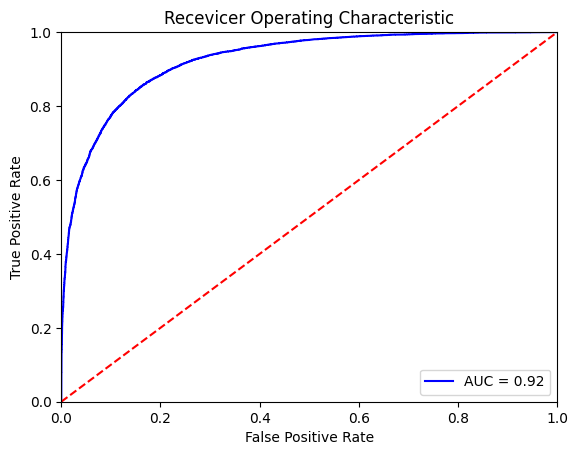

In [93]:
probs = bert_predict(bert_classifier, test_dataloader)

evaluate_roc(probs, y_test)
evaluate_roc

In [119]:
from sklearn.metrics import classification_report, confusion_matrix


Confusion Matrix:
          Negative  Positive
Negative      8864      1211
Positive      1948      7977


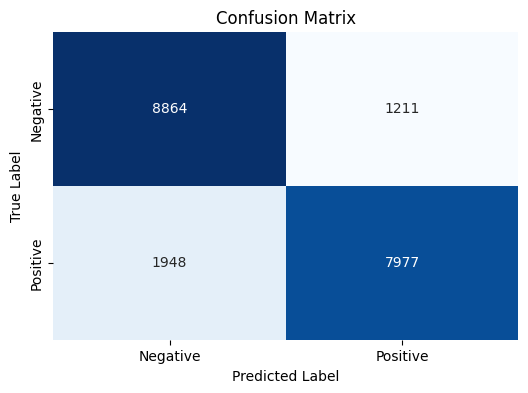

In [122]:
# confusion matrix for the best ANN model
cm = confusion_matrix(y_test, probs_1)

labels = ["Negative", "Positive"]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("\nConfusion Matrix:")
print(cm_df)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"], cbar = False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [115]:
report = classification_report(probs_1,y_test)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85     10257
           1       0.84      0.85      0.84      9743

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



AUC :  0.924852
Accuracy : 84.54%


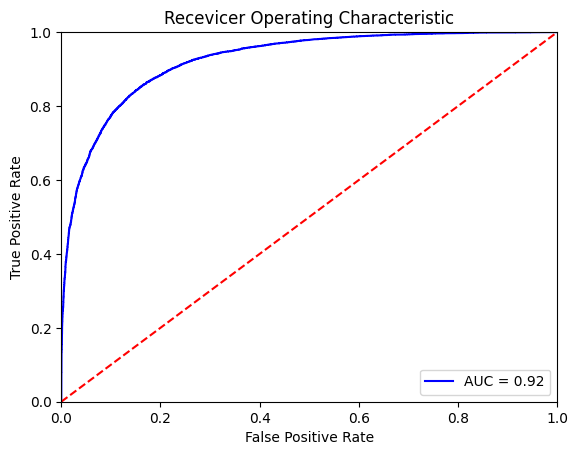

In [96]:
evaluate_roc(probs, y_test)
# evaluate_roc

## 5. Saving the model

## 4. Prediction of Test Set

In [116]:
X_Test.sample(5)

,text
1500741,Thank you for letting me fall asleep with a sm...
139340,working on getting stick thin even though it's...
744604,"ahh! i wish my phone was in working order, i w..."
781737,not doing cip @ breast cancer cus kiki got qua...
985605,Survived my first day of work....yeah! Early m...


In [117]:
y_test.sample(5)

,target
631348,0
1296162,1
1172332,1
704800,0
30778,0


In [ ]:
# Tokenize Test data
print("Tokenizing Test data ......")
test_inputs, test_masks = preprocessing_for_bert(X_Test)

# Data loader for test data
test_dataset = TensorDataset(test_inputs, test_masks)
test_sampler = SequentialSampler(test_dataset)
test_dataloader = DataLoader(test_dataset, sampler = test_sampler, batch_size = 32)

Tokenizing Test data ......


In [ ]:
# compute predicted probabilites on the test set
probs = bert_predict(bert_classifier, test_dataloader)

# get predictions from probabilities
threshold = 0.992
preds = np.where(probs[:,1]> threshold, 1, 0)

# Number of tweets predicted non-negative
print("Number of tweets predicted non-negative", preds.sum())


Number of tweets predicted non-negative 977
